In [ ]:
# AI-Based Citizen Grievance & Sentiment Analysis

# Objective:
# Build an NLP model to classify complaints into departments and analyze sentiment (positive/negative)

In [ ]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.6 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JATIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JATIN\AppData\Roaming\nltk_data...


True

In [ ]:
# Load Dataset
df = pd.read_csv(r"C:\Users\JATIN\Desktop\drs sem 4\complaints_500.csv")

df.head()

,text,department,sentiment
0,water leakage in area,water,negative
1,garbage not collected,sanitation,negative
2,water supply not working,water,negative
3,water leakage in area,water,negative
4,potholes on road,road,negative


In [ ]:
# Basic Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        500 non-null    object
 1   department  500 non-null    object
 2   sentiment   500 non-null    object
dtypes: object(3)
memory usage: 11.8+ KB


,text,department,sentiment
count,500,500,500
unique,20,4,2
top,electricity working fine,road,negative
freq,34,133,370


In [ ]:
# Missing Values
df.isnull().sum()

text          0
department    0
sentiment     0
dtype: int64

In [5]:
# Text Cleaning
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stopwords.words('english')]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

df.head()

,text,department,sentiment,clean_text
0,water leakage in area,water,negative,water leakage area
1,garbage not collected,sanitation,negative,garbage collected
2,water supply not working,water,negative,water supply working
3,water leakage in area,water,negative,water leakage area
4,potholes on road,road,negative,pothole road


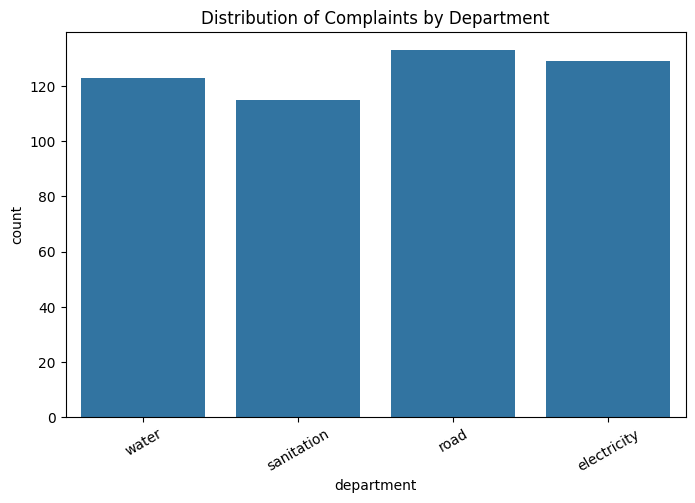

In [6]:
# Visualization – Department
plt.figure(figsize=(8,5))
sns.countplot(x='department', data=df)
plt.title("Distribution of Complaints by Department")
plt.xticks(rotation=30)
plt.show()

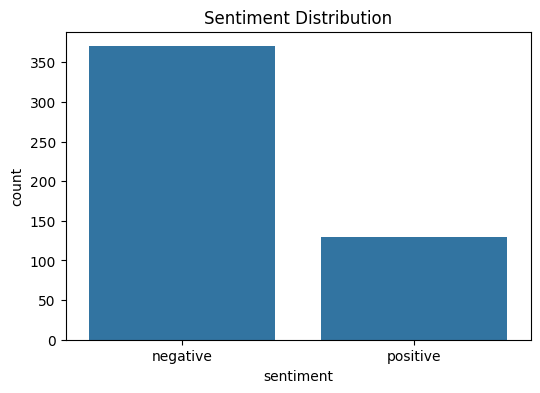

In [7]:
# Visualization – Sentiment
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

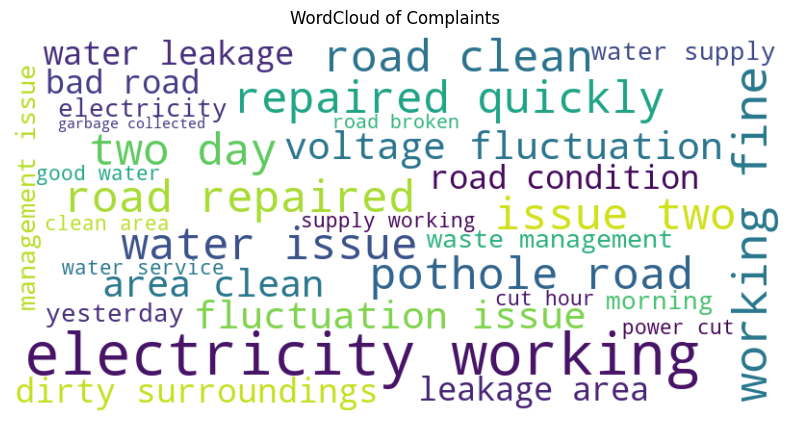

In [8]:
# WordCloud
text_data = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Complaints")
plt.show()

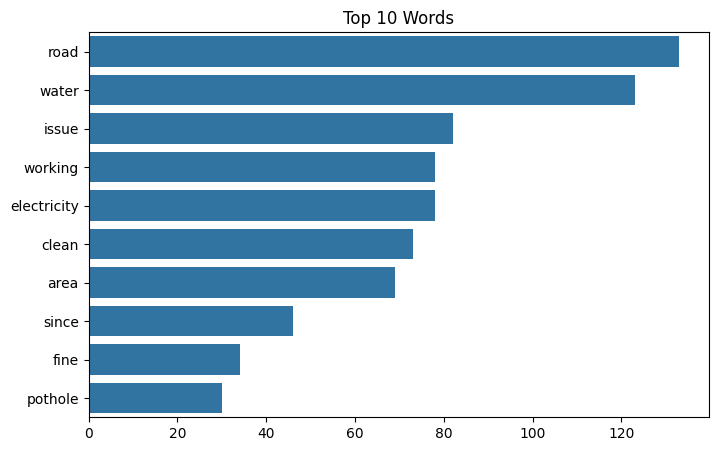

In [9]:
# Top Words
all_words = text_data.split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(8,5))
sns.barplot(x=counts, y=words)
plt.title("Top 10 Words")
plt.show()

In [10]:
# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])

In [11]:
# Department Model
y_dept = df['department']

X_train, X_test, y_train, y_test = train_test_split(X, y_dept, test_size=0.2, random_state=42)

model_dept = LogisticRegression(max_iter=200)
model_dept.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


              precision    recall  f1-score   support

 electricity       1.00      1.00      1.00        26
        road       1.00      1.00      1.00        26
  sanitation       1.00      1.00      1.00        21
       water       1.00      1.00      1.00        27

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



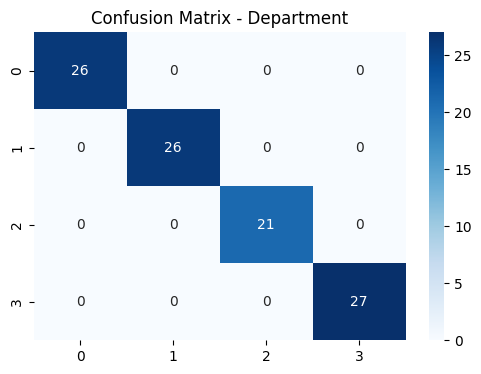

In [12]:
# Department Evaluation
y_pred = model_dept.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Department")
plt.show()

In [13]:
# Sentiment Model
y_sent = df['sentiment']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_sent, test_size=0.2, random_state=42)

model_sent = LogisticRegression(max_iter=200)
model_sent.fit(X_train2, y_train2)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        77
    positive       1.00      1.00      1.00        23

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



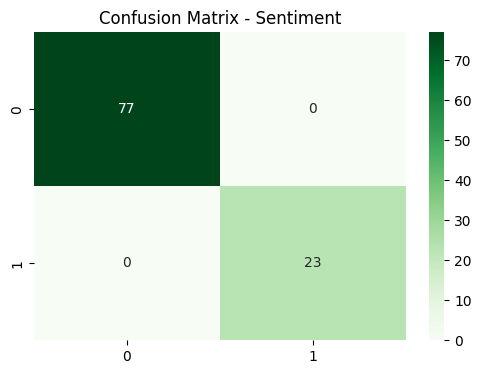

In [14]:
# Sentiment Evaluation
y_pred2 = model_sent.predict(X_test2)

print(classification_report(y_test2, y_pred2))

cm2 = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Sentiment")
plt.show()

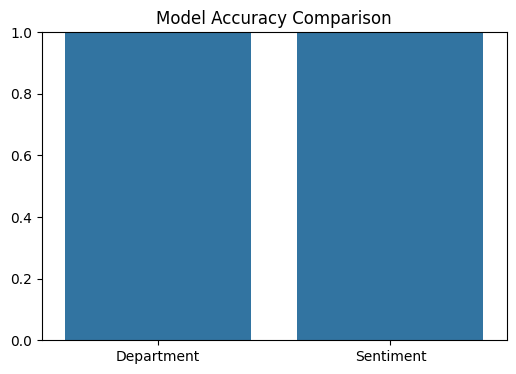

In [15]:
# Accuracy Comparison
dept_acc = model_dept.score(X_test, y_test)
sent_acc = model_sent.score(X_test2, y_test2)

models = ['Department', 'Sentiment']
accuracy = [dept_acc, sent_acc]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracy)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

In [16]:
# Save Model
joblib.dump(model_dept, "dept_model.pkl")
joblib.dump(model_sent, "sent_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [17]:
# Prediction Function
def predict(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    
    dept = model_dept.predict(vec)[0]
    sent = model_sent.predict(vec)[0]
    
    return dept, sent

predict("electricity issue since yesterday")

('electricity', 'negative')